In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

In [2]:
df=pd.read_csv("bodyPerformance.csv")
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


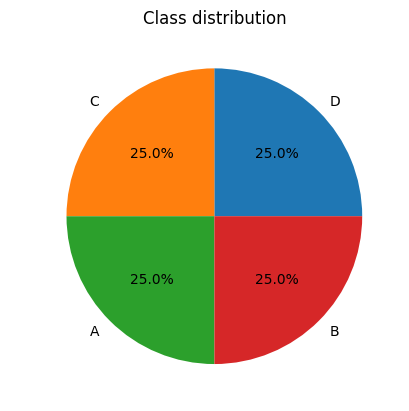

In [3]:
df=df[df['class']!='?']
df['class'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Class distribution')
plt.ylabel(' ')
plt.show()

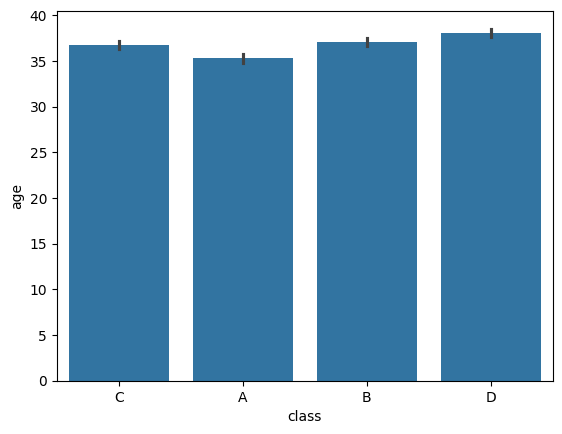

In [4]:
sns.barplot(x='class',y='age',data=df)
plt.show()

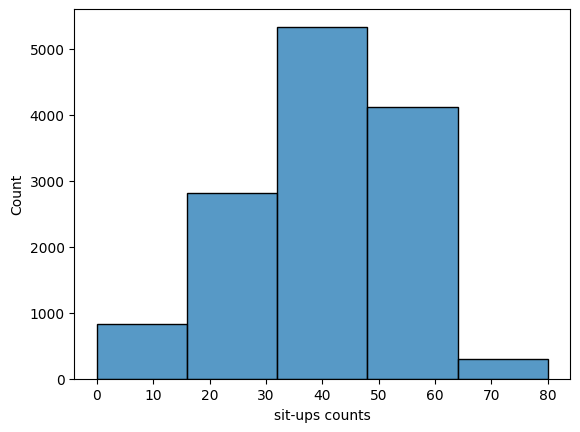

In [5]:
sns.histplot(data=df,x='sit-ups counts',bins=5)
plt.show()

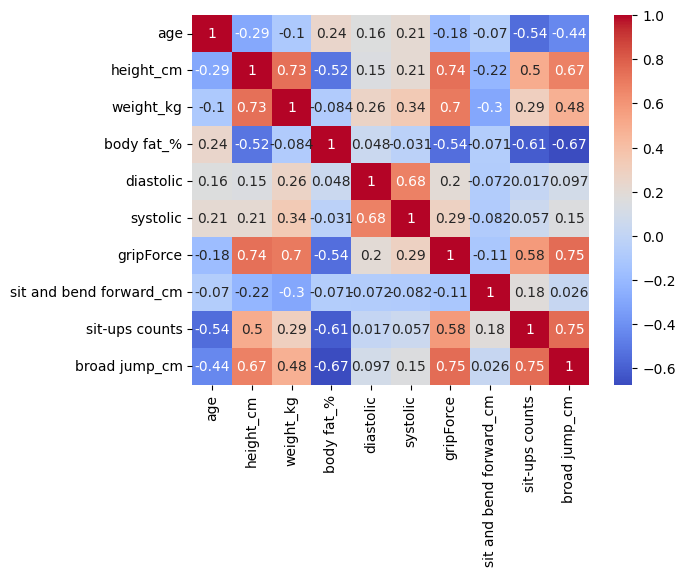

In [6]:
cor=df.corr(numeric_only=True)
sns.heatmap(cor,annot=True,cmap='coolwarm')
plt.show()

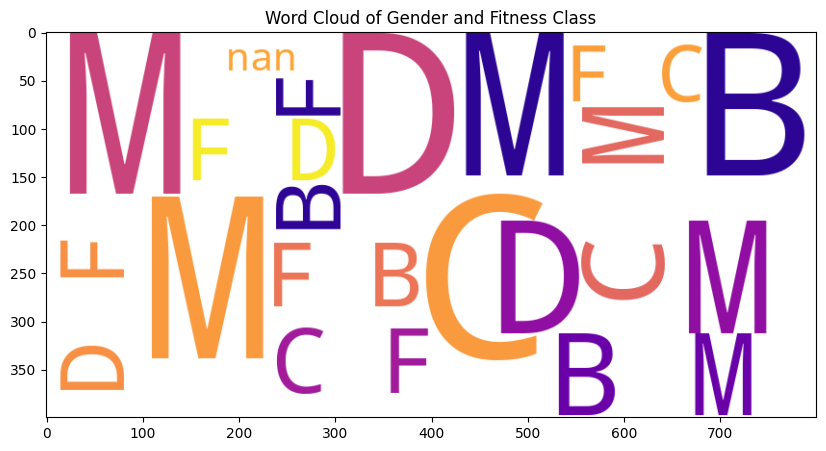

In [10]:
from wordcloud import WordCloud

text=" ".join(df["gender"].astype(str)+" "+df["class"].astype(str))
wc=WordCloud(width=800,height=400,background_color="white",colormap="plasma").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.title("Word Cloud of Gender and Fitness Class")
plt.show()

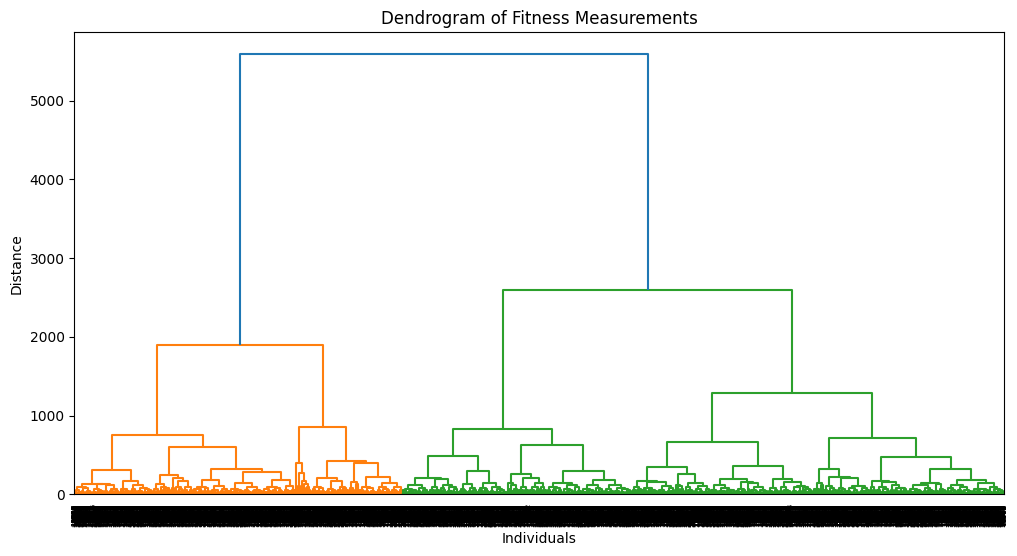

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage

features = df[["height_cm","weight_kg","body fat_%","gripForce","broad jump_cm"]].dropna()

Z=linkage(features, method="ward")

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Dendrogram of Fitness Measurements")
plt.xlabel("Individuals")
plt.ylabel("Distance")
plt.show()

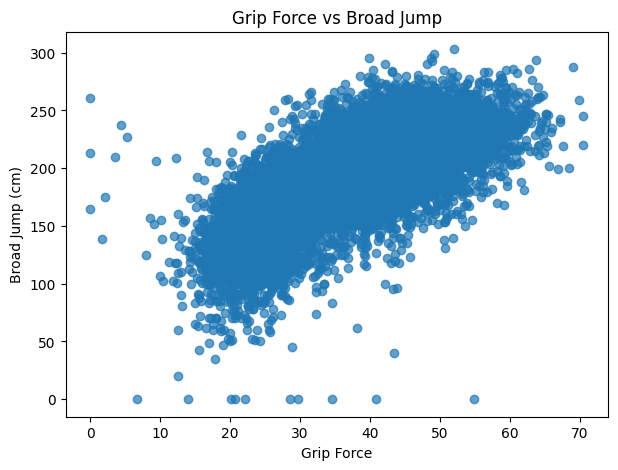

In [16]:
plt.figure(figsize=(7,5))
plt.scatter(df["gripForce"], df["broad jump_cm"], alpha=0.7)

plt.xlabel("Grip Force")
plt.ylabel("Broad Jump (cm)")
plt.title("Grip Force vs Broad Jump")
plt.show()

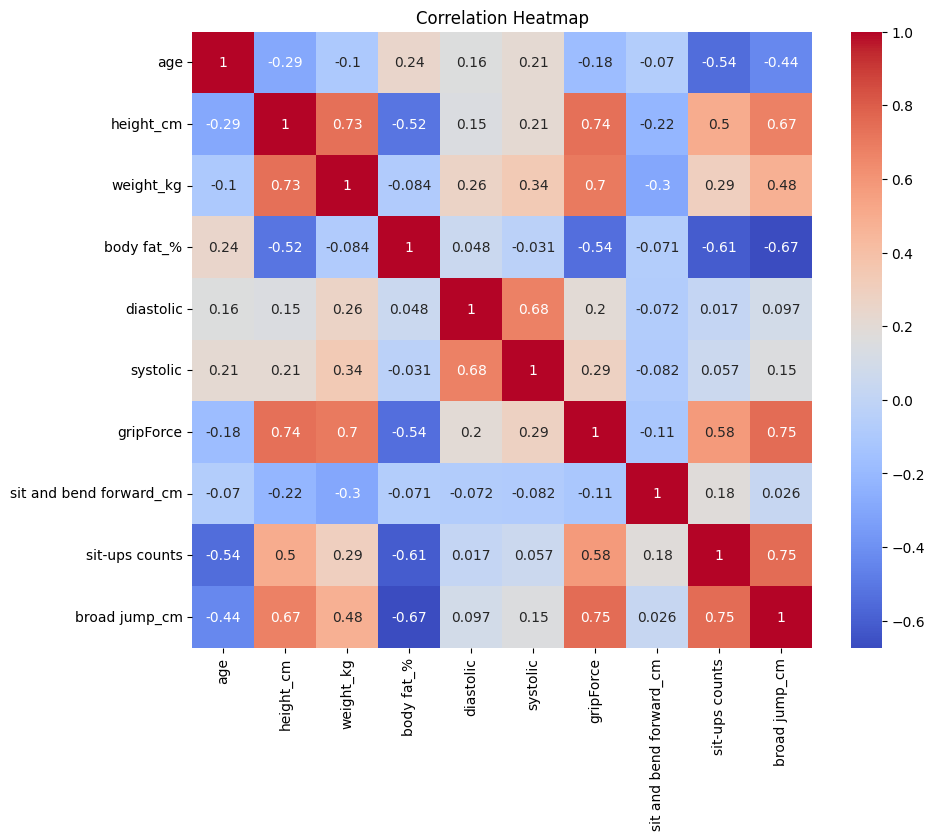

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

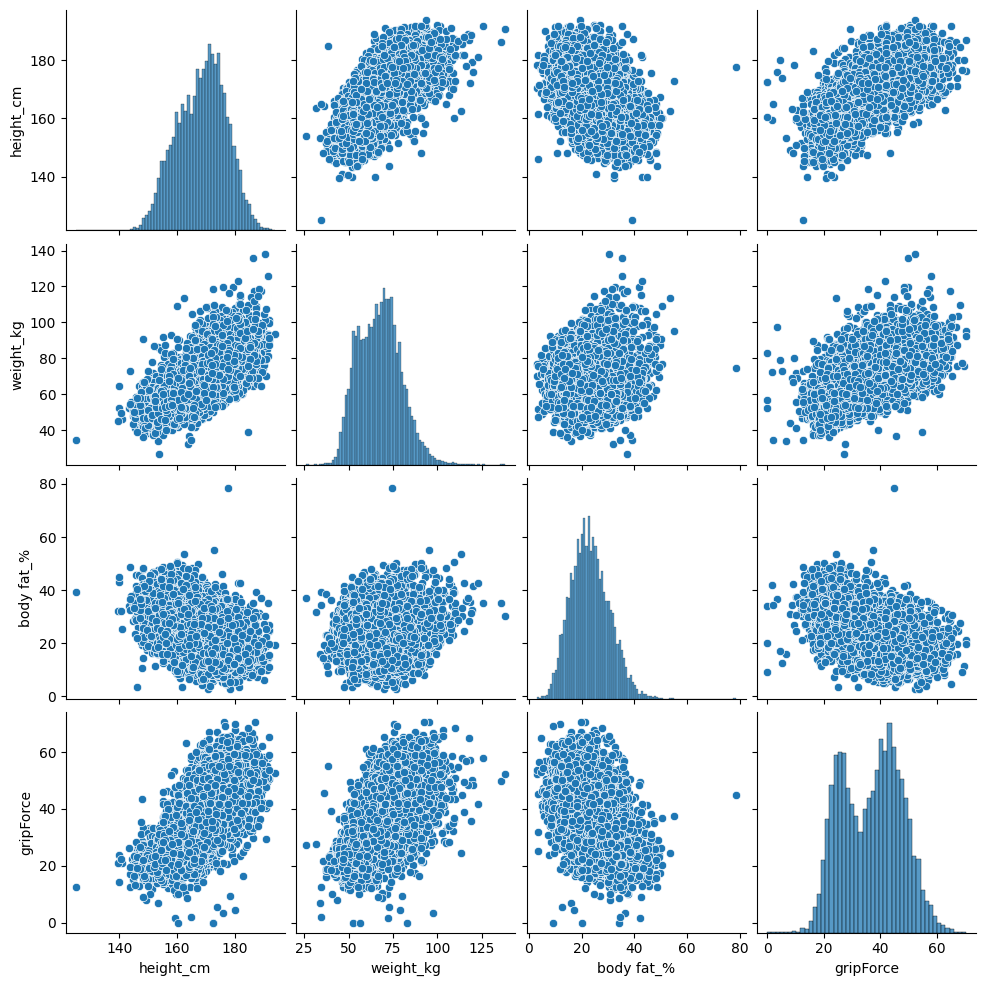

In [21]:
sns.pairplot(df,vars=["height_cm","weight_kg","body fat_%","gripForce"])
plt.show()

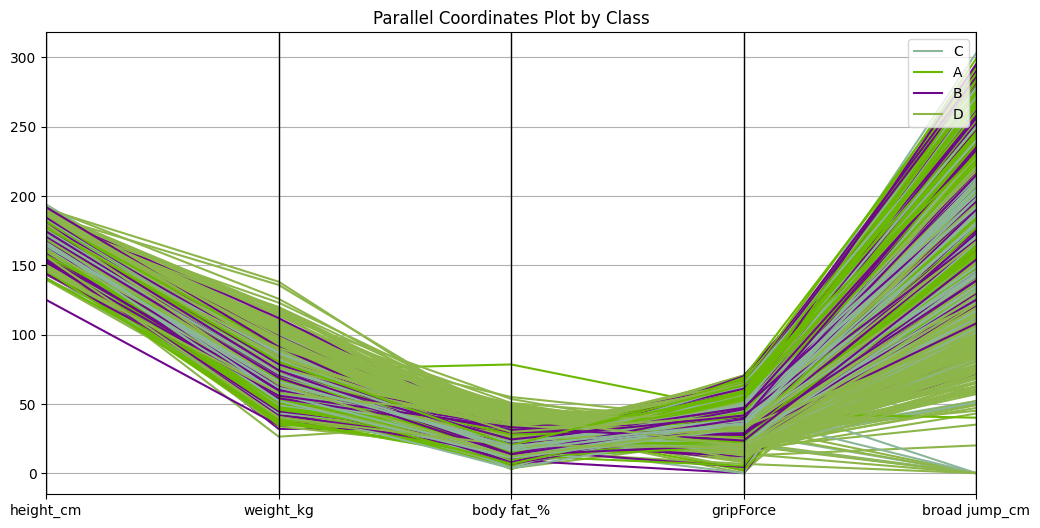

In [28]:
from pandas.plotting import parallel_coordinates

parallel_df=df[["height_cm","weight_kg","body fat_%","gripForce","broad jump_cm","class"]].dropna()
plt.figure(figsize=(12,6))
parallel_coordinates(parallel_df, "class")

plt.title("Parallel Coordinates Plot by Class")
plt.grid(True)
plt.show()

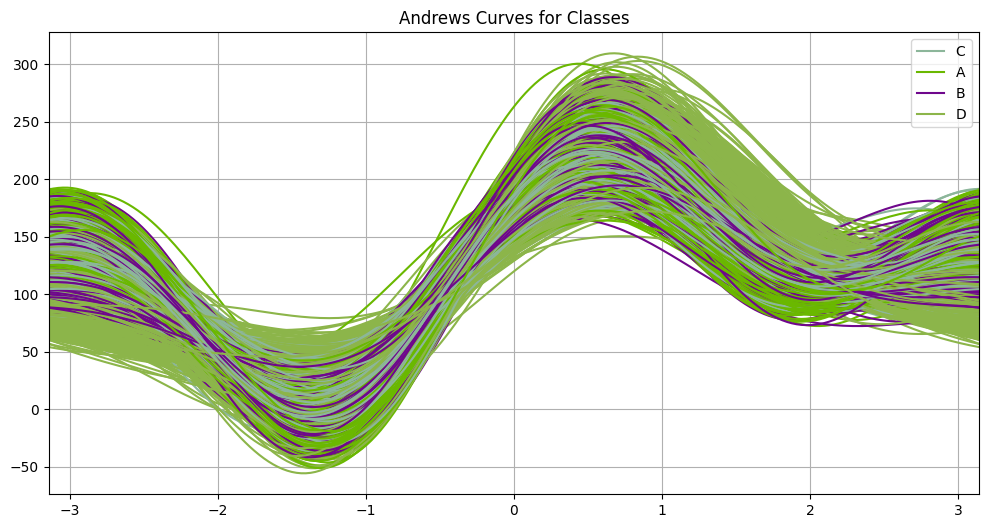

In [27]:
from pandas.plotting import andrews_curves

andrews_df=df[["height_cm","weight_kg","body fat_%","gripForce","sit-ups counts","class"]].dropna()
plt.figure(figsize=(12,6))
andrews_curves(andrews_df, "class")

plt.title("Andrews Curves for Classes")
plt.grid(True)
plt.show()